In [2]:
import pandas as pd

In [3]:
centerOneandOthers = pd.read_excel("../Dataset/Cleaned_dataset.xlsx")
externalSet = pd.read_excel("Dataset/cleaned_external.xlsx")


In [4]:
centerOneandOthers.shape

(1046, 128)

In [5]:
externalSet.shape

(334, 128)

In [6]:
col = "maligno"

# split del dataset centerOneandOthers
center_1 = centerOneandOthers[centerOneandOthers["luogoTC_codificato"] == 1]
center_other = centerOneandOthers[centerOneandOthers["luogoTC_codificato"] != 1]

# prevalence
prev_df = pd.DataFrame({
    "center_luogoTC_1": center_1[col].value_counts(normalize=True) * 100,
    "center_luogoTC_not1": center_other[col].value_counts(normalize=True) * 100,
    "externalSet": externalSet[col].value_counts(normalize=True) * 100
})

print(prev_df)

         center_luogoTC_1  center_luogoTC_not1  externalSet
maligno                                                    
0                78.58473            81.532417     70.05988
1                21.41527            18.467583     29.94012


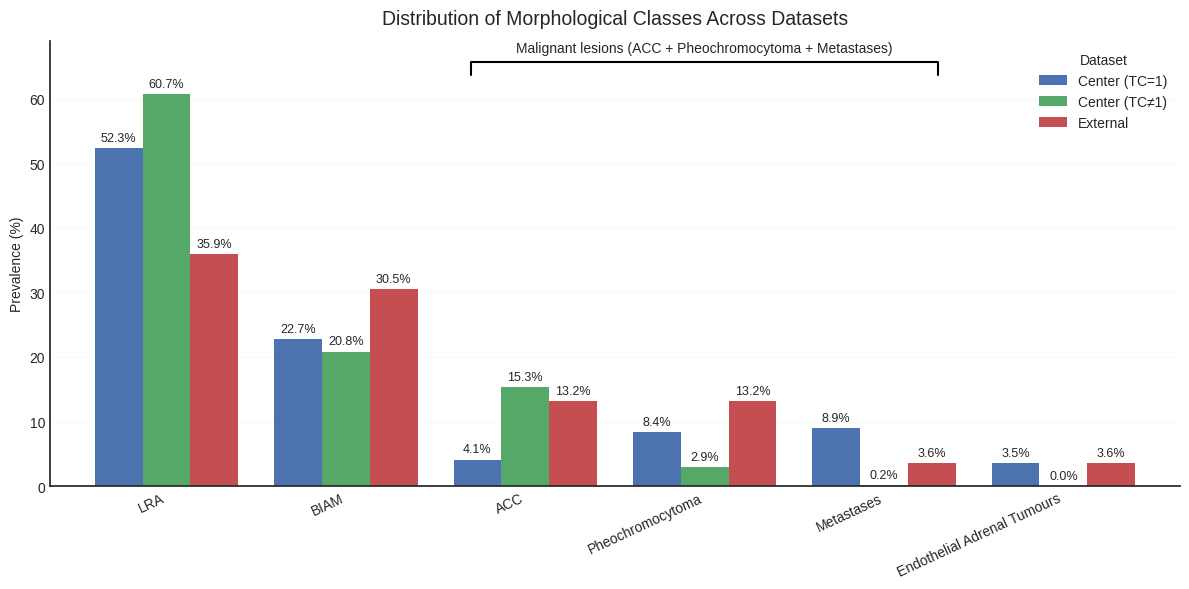

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-white")

classes = [
    "LRA",
    "BIAM",
    "ACC",
    "Pheochromocytoma",
    "Metastases",
    "Endothelial Adrenal Tumours"
]

def get_dist(df):
    return df["morf_codificata"].value_counts(normalize=True).reindex(range(6), fill_value=0) * 100

# split dataset
center_1 = centerOneandOthers[centerOneandOthers["luogoTC_codificato"] == 1]
center_other = centerOneandOthers[centerOneandOthers["luogoTC_codificato"] != 1]

dist_df = pd.DataFrame({
    "Center (TC=1)": get_dist(center_1).values,
    "Center (TC≠1)": get_dist(center_other).values,
    "External": get_dist(externalSet).values
}, index=classes)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#4C72B0", "#55A868", "#C44E52"]

dist_df.plot(kind="bar", ax=ax, width=0.8, color=colors)

ax.set_title("Distribution of Morphological Classes Across Datasets", fontsize=14, pad=12)
ax.set_ylabel("Prevalence (%)")
ax.set_xlabel("")
ax.set_xticklabels(classes, rotation=25, ha="right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

ax.legend(frameon=False, title="Dataset")


def add_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c="black")
    ax.text((x1+x2)/2, y+h+1, text, ha="center", va="bottom", fontsize=10)

y_max = dist_df.values.max()

x1, x2 = 1.7, 4.3

add_bracket(
    ax,
    x1,
    x2,
    y=y_max + 3,
    h=2,
    text="Malignant lesions (ACC + Pheochromocytoma + Metastases)"
)

plt.tight_layout()
plt.show()

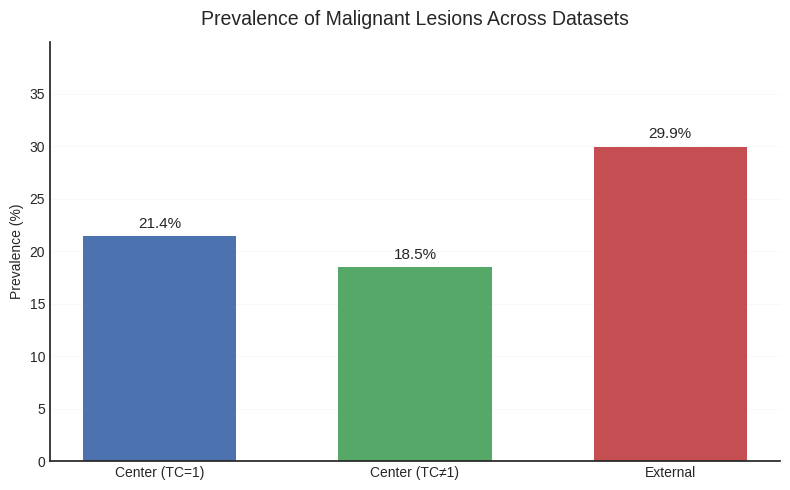

In [8]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-white")

def malignant_prevalence(df):
    dist = df["morf_codificata"].value_counts(normalize=True)
    return (dist.reindex([2, 3, 4], fill_value=0).sum()) * 100

malignant_df = pd.DataFrame({
    "Center (TC=1)": [malignant_prevalence(centerOneandOthers[centerOneandOthers["luogoTC_codificato"] == 1])],
    "Center (TC≠1)": [malignant_prevalence(centerOneandOthers[centerOneandOthers["luogoTC_codificato"] != 1])],
    "External": [malignant_prevalence(externalSet)]
}, index=["Malignant (2–4)"])

fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#4C72B0", "#55A868", "#C44E52"]

bars = ax.bar(malignant_df.columns, malignant_df.loc["Malignant (2–4)"], color=colors, width=0.6)

ax.set_title("Prevalence of Malignant Lesions Across Datasets", fontsize=14, pad=12)
ax.set_ylabel("Prevalence (%)")
ax.set_ylim(0, max(malignant_df.loc["Malignant (2–4)"]) + 10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.savefig("images/prevalence.png")
plt.show()

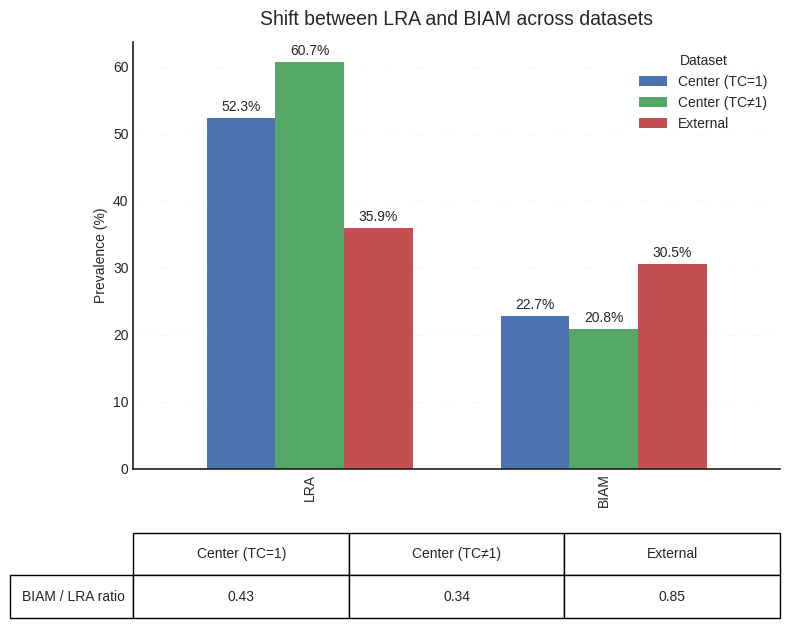

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-white")

classes_focus = [0, 1]
labels_focus = ["LRA", "BIAM"]

def get_focus_dist(df):
    return df["morf_codificata"].value_counts(normalize=True).reindex(classes_focus, fill_value=0) * 100

center_1 = centerOneandOthers[centerOneandOthers["luogoTC_codificato"] == 1]
center_other = centerOneandOthers[centerOneandOthers["luogoTC_codificato"] != 1]

focus_df = pd.DataFrame({
    "Center (TC=1)": get_focus_dist(center_1).values,
    "Center (TC≠1)": get_focus_dist(center_other).values,
    "External": get_focus_dist(externalSet).values
}, index=labels_focus)

fig, ax = plt.subplots(figsize=(8, 6))

colors = ["#4C72B0", "#55A868", "#C44E52"]

focus_df.plot(kind="bar", ax=ax, color=colors, width=0.7)

ax.set_title("Shift between LRA and BIAM across datasets", fontsize=14, pad=12)
ax.set_ylabel("Prevalence (%)")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=10, padding=3)

ax.legend(frameon=False, title="Dataset")

lra = focus_df.loc["LRA"]
biam = focus_df.loc["BIAM"]
ratio = (biam / lra).round(2)

ratio_table = pd.DataFrame({
    "Center (TC=1)": [ratio["Center (TC=1)"]],
    "Center (TC≠1)": [ratio["Center (TC≠1)"]],
    "External": [ratio["External"]]
}, index=["BIAM / LRA ratio"])


plt.subplots_adjust(bottom=0.35)

table = plt.table(
    cellText=ratio_table.values,
    colLabels=ratio_table.columns,
    rowLabels=ratio_table.index,
    cellLoc="center",
    loc="bottom",
    bbox=[0, -0.35, 1, 0.2]  
)

table.scale(1, 1.2)
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.tight_layout()
plt.savefig("images/bening_shift.png", dpi=300, bbox_inches="tight")
plt.show()

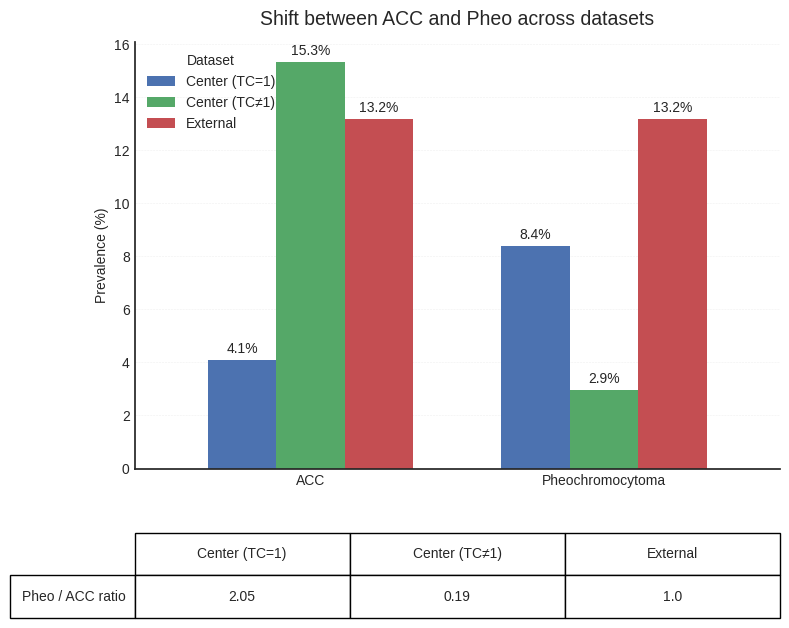

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-white")

classes_focus = [2, 3]
labels_focus  = ["ACC", "Pheochromocytoma"]

def get_focus_dist(df):
    return df["morf_codificata"].value_counts(normalize=True).reindex(classes_focus, fill_value=0) * 100

center_1     = centerOneandOthers[centerOneandOthers["luogoTC_codificato"] == 1]
center_other = centerOneandOthers[centerOneandOthers["luogoTC_codificato"] != 1]

focus_df = pd.DataFrame({
    "Center (TC=1)": get_focus_dist(center_1).values,
    "Center (TC≠1)": get_focus_dist(center_other).values,
    "External":      get_focus_dist(externalSet).values
}, index=labels_focus)

# ---------------- PLOT ----------------
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#4C72B0", "#55A868", "#C44E52"]

focus_df.plot(kind="bar", ax=ax, color=colors, width=0.7)
ax.set_title("Shift between ACC and Pheo across datasets", fontsize=14, pad=12)
ax.set_ylabel("Prevalence (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)  # ← fix bug label
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=10, padding=3)

ax.legend(frameon=False, title="Dataset")

acc  = focus_df.loc["ACC"]
pheo = focus_df.loc["Pheochromocytoma"]

ratio = (pheo / acc.replace(0, float("nan"))).round(2)

ratio_table = pd.DataFrame({
    "Center (TC=1)": [ratio["Center (TC=1)"]],
    "Center (TC≠1)": [ratio["Center (TC≠1)"]],
    "External": [ratio["External"]]
}, index=["Pheo / ACC ratio"])

plt.subplots_adjust(bottom=0.35)

table = plt.table(
    cellText=ratio_table.values,
    colLabels=ratio_table.columns,
    rowLabels=ratio_table.index,
    cellLoc="center",
    loc="bottom",
    bbox=[0, -0.35, 1, 0.2]  
)

table.scale(1, 1.2)
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.tight_layout()
plt.savefig("images/malign_shift.png", dpi=300, bbox_inches="tight")
plt.show()